#### Random Sample Inputation
It is used when data are missing complettely at random

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [42]:
df=pd.read_csv('titanic.csv',usecols=['Age','Survived','Fare'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [43]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [44]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [45]:
df['Age'].dropna().sample()

456    65.0
Name: Age, dtype: float64

In [46]:
df['Age'].dropna().sample(df['Age'].isnull().sum(),random_state=0)

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [47]:
df['Age'].dropna().sample(177,random_state=0) #same

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [54]:
def fill_nan(df,feature,median):
    df[feature + '_median']=df[feature].fillna(median)
    df[feature + '_random']=df[feature]
    random_sample=df[feature].dropna().sample(df[feature].isnull().sum() ,random_state=0)
    # creating n random sample
    random_sample.index=df[df[feature].isnull()].index
    df.loc[df['Age'].isnull(),feature + '_random']=random_sample

In [55]:
median=df['Age'].median()
median

np.float64(28.0)

In [56]:
fill_nan(df,"Age", median)

In [57]:
df.head()

,Survived,Age,Fare,Age_median,Age_random
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


In [59]:
df[df['Age'].isnull()]

,Survived,Age,Fare,Age_median,Age_random
5,0,NaN,8.4583,28.0,28.00
17,1,NaN,13.0000,28.0,50.00
19,1,NaN,7.2250,28.0,0.92
26,0,NaN,7.2250,28.0,36.00
28,1,NaN,7.8792,28.0,26.00
...,...,...,...,...,...
859,0,NaN,7.2292,28.0,22.00
863,0,NaN,69.5500,28.0,25.00
868,0,NaN,9.5000,28.0,15.00
878,0,NaN,7.8958,28.0,34.00


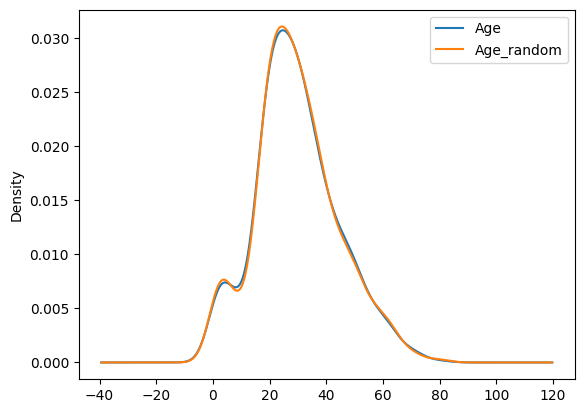

In [66]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['Age'].plot(kind='kde')
df['Age_random'].plot(kind='kde')
lines,label=ax.get_legend_handles_labels()
ax.legend(lines,label)

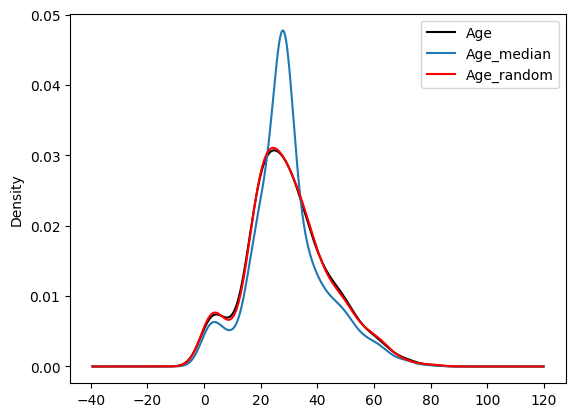

In [70]:
#with median replace 
fig=plt.figure()
ax=fig.add_subplot(111)
df['Age'].plot(kind='kde',color='black')
df['Age_median'].plot(kind='kde')
df['Age_random'].plot(kind='kde', color='red')
lines,label=ax.get_legend_handles_labels()
ax.legend(lines,label)

#### Advantages
1. easy to implement
2. there is lesss distoration

#### disadvantage
1. In every situation randomness dont  work